In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import curve_fit

gs_basic = pd.read_csv("data/example_data.csv")
pwat = pd.read_csv("data/pwat_regional.csv")
sst = pd.read_csv("data/sst_regional.csv")

gs_boston = gs_basic[gs_basic['station_name'] == "Boston Logan, MA"]
gs_new_york = gs_basic[gs_basic['station_name'] == "Central Park, NY"]
gs_raleigh = gs_basic[gs_basic['station_name'] == "Raleigh-Durham, NC"]
gs_miami = gs_basic[gs_basic['station_name'] == "Miami, FL"]
gs_nashville = gs_basic[gs_basic['station_name'] == "Nashville, TN"]
gs_chicago = gs_basic[gs_basic['station_name'] == "Chicago OHare, IL"]
gs_burlington = gs_basic[gs_basic['station_name'] == "Burlington, VT"]
gs_atlanta = gs_basic[gs_basic['station_name'] == "Atlanta, GA"]
gs_pittsburgh = gs_basic[gs_basic['station_name'] == "Pittsburgh, PA"]
gs_nola = gs_basic[gs_basic['station_name'] == "New Orleans, LA"]
gs_portland = gs_basic[gs_basic['station_name'] == "Portland, ME"]
gs_richmond = gs_basic[gs_basic['station_name'] == "Richmond, VA"]
gs_pwat_boston = pd.merge(gs_boston, pwat, on = 'year')
gs_pwat_new_york = pd.merge(gs_new_york, pwat, on = 'year')
gs_pwat_raleigh = pd.merge(gs_raleigh, pwat, on = 'year')
gs_pwat_miami = pd.merge(gs_miami, pwat, on = 'year')
gs_pwat_nashville = pd.merge(gs_nashville, pwat, on = 'year')
gs_pwat_chicago = pd.merge(gs_chicago, pwat, on = 'year')
gs_pwat_burlington = pd.merge(gs_burlington, pwat, on = 'year')
gs_pwat_atlanta = pd.merge(gs_atlanta, pwat, on = 'year')
gs_pwat_pittsburgh = pd.merge(gs_pittsburgh, pwat, on = 'year')
gs_pwat_nola = pd.merge(gs_nola, pwat, on = 'year')
gs_pwat_portland = pd.merge(gs_portland, pwat, on = 'year')
gs_pwat_richmond = pd.merge(gs_richmond, pwat, on = 'year')
gs_pwat_sst_boston = pd.merge(gs_pwat_boston, sst, on = 'year')
gs_pwat_sst_new_york = pd.merge(gs_pwat_new_york, sst, on = 'year')
gs_pwat_sst_raleigh = pd.merge(gs_pwat_raleigh, sst, on = 'year')
gs_pwat_sst_miami = pd.merge(gs_pwat_miami, sst, on = 'year')
gs_pwat_sst_nashville = pd.merge(gs_pwat_nashville, sst, on = 'year')
gs_pwat_sst_chicago = pd.merge(gs_pwat_chicago, sst, on = 'year')
gs_pwat_sst_burlington = pd.merge(gs_pwat_burlington, sst, on = 'year')
gs_pwat_sst_atlanta = pd.merge(gs_pwat_atlanta, sst, on = 'year')
gs_pwat_sst_pittsburgh = pd.merge(gs_pwat_pittsburgh, sst, on = 'year')
gs_pwat_sst_nola = pd.merge(gs_pwat_nola, sst, on = 'year')
gs_pwat_sst_portland = pd.merge(gs_pwat_portland, sst, on = 'year')
gs_pwat_sst_richmond = pd.merge(gs_pwat_richmond, sst, on = 'year')
gs_cities = [gs_pwat_sst_boston, gs_pwat_sst_new_york, gs_pwat_sst_raleigh, gs_pwat_sst_miami, 
                    gs_pwat_sst_nashville, gs_pwat_sst_chicago, gs_pwat_sst_burlington,
                    gs_pwat_sst_atlanta, gs_pwat_sst_pittsburgh, gs_pwat_sst_nola, 
                    gs_pwat_sst_portland, gs_pwat_sst_richmond]
gs = pd.concat(gs_cities)

In [2]:
gs_cleaned = gs.dropna()

In [3]:
coastal_stations = gs_cleaned[(gs_cleaned['station_name'] == 'Boston Logan, MA') | (gs_cleaned['station_name'] == "Central Park, NY") |
    (gs_cleaned['station_name'] == "Miami, FL") | (gs_cleaned['station_name'] == "New Orleans, LA") | 
    (gs_cleaned['station_name'] == "Portland, ME") |(gs_cleaned['station_name'] == "Richmond, VA")]
inland_stations = gs_cleaned[(gs_cleaned['station_name'] == "Atlanta, GA") | (gs_cleaned['station_name'] == "Nashville, TN") |
                      (gs_cleaned['station_name'] == "Pittsburgh, PA") |(gs_cleaned['station_name'] == "Raleigh-Durham, NC")]
lakeside_stations = gs_cleaned[(gs_cleaned['station_name'] == "Chicago OHare, IL") | (gs_cleaned['station_name'] == "Pittsburgh, PA") | 
    (gs_cleaned['station_name'] == "Burlington, VT")]

In [4]:
data_vars = {'oni_annual':'Annual mean Oceanic Niño Index','nao_annual':['Annual mean North Atlantic Oscillation','Annual Mean NAO'], 
            'nao_djf':['Winter (Jan–Feb) mean North Atlantic Oscillation','Winter Mean NAO'],
            'pna_annual':['Annual mean Pacific-North American pattern','Annual Mean PNA'],
            'amo_annual': ['Annual mean Atlantic Multidecadal Oscillation', 'Annual Mean AMO'],
            'ohc700_atlantic':['Full Atlantic Ocean 0–700m OHC anomaly','Full Atlantic OHC Anom.'],
            'ohc700_north_atlantic':['North Atlantic 0–700m OHC anomaly','N. Atlantic OHC Anom.'],
            'ohc700_south_atlantic':['South Atlantic 0–700m OHC anomaly','S. Atlantic OHC Anom.'], 
            'ohc2000_north_atlantic':['North Atlantic 0–2000m OHC anomaly','N. Atl. 2000m OHC Anom.'],
            'ohc700_pacific':['Pacific Ocean 0–700m OHC anomaly','Pacific OHC Anom.'],
            'ohc700_world':['World Ocean 0–700m OHC anomaly','World OHC Anom.'],
            'ohc700_natl_djf':['Winter (Oct–Mar) mean North Atlantic 0–700m OHC','Winter N. Atl. OHC'],
            'ohc700_natl_amj':['Spring (Apr–Jun) mean North Atlantic 0–700m OHC','Spring N. Atl. OHC'], 
            'sst_north_atlantic':['Full North Atlantic Sea Surface Temperature (deg C)','N. Atl. SST'], 
            'sst_gulf_stream':['Gulf Stream/Western North Atlantic Sea Surface Temperature (deg C)','Gulf Stream SST'],
            'sst_gulf_mexico':['Gulf of Mexico Sea Surface Temperature (deg C)','Gulf of MX SST'], 
            'sst_tropical_north_atl':['Tropical North Atlantic Sea Surface Temperature (deg C)','Trop. N. Atl. SST'],
            'pwat_eastern_us':['Eastern U.S. Monthly mean Precipitable Water (kg/m^2)','E. U.S. mean PWAT'],
            'pwat_southeast_us':['Southeastern U.S. Monthly mean Precipitable Water (kg/m^2)','S.E. U.S. mean PWAT'],
            'pwat_northeast_us':['Northeastern U.S. Monthly mean Precipitable Water (kg/m^2)','N.E. U.S. mean PWAT'],
            'pwat_gulf_coast':['Gulf Coast Monthly mean Precipitable Water (kg/m^2)','Gulf Coast mean PWAT']}

#for var,label in data_vars.items():
    mc,bc = np.polyfit(coastal_stations['growing_season_length'], coastal_stations[var], 1)
    mi,bi = np.polyfit(inland_stations['growing_season_length'], inland_stations[var], 1)
    ml,bl = np.polyfit(lakeside_stations['growing_season_length'], lakeside_stations[var], 1)
    
    line_c = mc * coastal_stations['growing_season_length'] + bc
    line_i = mi * inland_stations['growing_season_length'] + bi
    line_l = ml * lakeside_stations['growing_season_length'] + bl
    
    plt.scatter(coastal_stations['growing_season_length'], coastal_stations[var], c='b', label = f'{label[1]}')
    plt.scatter(inland_stations['growing_season_length'], inland_stations[var], c='g', label = f'{label[1]}')
    plt.scatter(lakeside_stations['growing_season_length'], lakeside_stations[var], c='r', label = f'{label[1]}')

    plt.plot(coastal_stations['growing_season_length'], line_c, c='tab:cyan', label = 'Best Fit (Coastal)')
    plt.plot(inland_stations['growing_season_length'], line_i, c='tab:purple', label = 'Best Fit (Inland)')
    plt.plot(lakeside_stations['growing_season_length'], line_l, c='tab:pink', label = 'Best Fit (lakeside)')
    
    plt.xlabel('Growing Season Length (days)')
    plt.ylabel(f'{label[0]}', fontsize = 'smaller')
    plt.title(f"Growing Season Length (days) vs {label[0]} w/ Best Linear Fit Line")
    
    plt.legend()
    
    plt.show()

IndentationError: unexpected indent (2231071186.py, line 23)

In [5]:
def scatter_best_fit(data_subset, data_subset_abv, xaxis, yaxis, xlabelfull, xlabelabv, ylabelfull, ylabelabv, deg_fit):
    # creates a scatter plot with a best fit line of choice, from a data set or subset, taking in column choices for the x axis
    # and y axis, preferred labels for each axis and the data set, and the desired degree of the line of best fit 

    #required libraries: numpy as np, matplotlib as plt, and curve_fit from scipy.optimize

    # creates line of best fit
    if deg_fit == 1:
        m,b = np.polyfit(data_subset[xaxis], data_subset[yaxis], 1)
        line = m * data_subset[xaxis] + b
    elif deg_fit == 2:
        a, b, e = np.polyfit(data_subset[xaxis], data_subset[yaxis], 2)
        line = a * (data_subset[xaxis]**2) + b * data_subset[xaxis] + e
    elif deg_fit == 3:
        a, b, c, e = np.polyfit(data_subset[xaxis], data_subset[yaxis], 3)
        line = a * (data_subset[xaxis]**3) + b * (data_subset[xaxis]**2) + c * data(subset[xaxis]) + e
    else:
        return print("please input a degree 1, 2, or 3")                                                                        

    #defines fit naming variable 'fit' based on degree of fit chosen, to be used in title
    if deg_fit == 1:
        fit = 'linear'
    elif deg_fit == 2:
        fit = 'quadratic'
    else:
        fit = 'cubic'

    #plots scatter plot and best fit line of choice, labels with chosen labels 
    plt.scatter(data_subset[xaxis], data_subset[yaxis], c = 'b', label = f'{ylabelabv}')
    plt.plot(data_subset[xaxis], line, c='tab:cyan', label = f'Best Fit ({data_subset_abv})')
    plt.title(f"{xlabelfull} vs {ylabelfull} w/ best {fit} fit")

    # creates a legend
    plt.legend()

    #returns plot
    return plt.show()

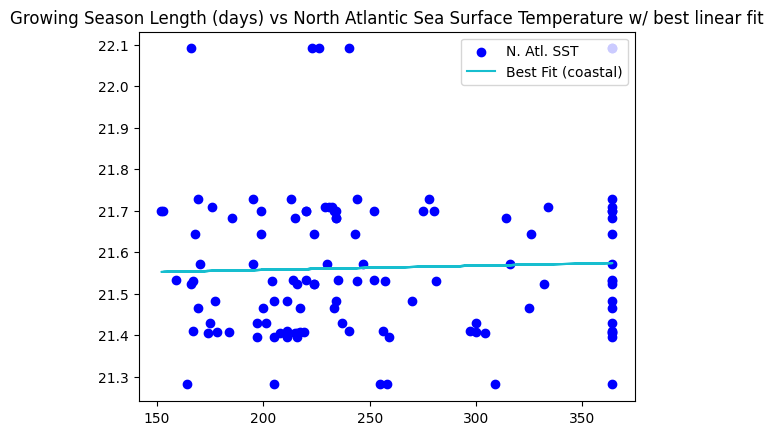

In [8]:
scatter_best_fit(coastal_stations, 'coastal', 'growing_season_length', 'sst_north_atlantic', 'Growing Season Length (days)',
                 'GS Length', 'North Atlantic Sea Surface Temperature', 'N. Atl. SST', 1)